# What is Chemical Diversity?

Chemical diversity refers to the degree of structural variation among molecules in a chemical library.

A chemically diverse dataset contains molecules with different scaffolds, functional groups, sizes, shapes, and physicochemical properties.

Conversely, a chemically similar dataset contains molecules that share many structural features.

Diversity analysis helps researchers quantify how varied a molecular dataset is and identify representative compounds for further study.

## Why Do We Need Diversity Analysis?

In drug discovery, chemical libraries often contain thousands or millions of molecules.

Testing every molecule experimentally is expensive and time-consuming.

Instead, researchers perform diversity analysis to:

- Select representative molecules
- Avoid testing many nearly identical compounds
- Maximize chemical coverage
- Improve screening efficiency
- Build balanced machine learning datasets

✓ Chemical diversity measures how structurally different molecules are.

✓ High diversity means broad chemical coverage.

✓ Low diversity means many structurally similar molecules.

✓ Diversity analysis helps select representative molecules and reduces unnecessary experimental testing.

✓ It plays a key role in drug discovery, virtual screening, and QSAR modeling.

# how do we measure chemical Diversity?
# Before measuring diversity, we first need to understand similarity.

## Similarity vs Diversity

Chemical diversity and chemical similarity are opposite concepts.

- If two molecules are highly similar, they contribute very little to the diversity of the dataset.
- If two molecules are very different, they increase the diversity of the dataset.

Therefore,

High Similarity → Low Diversity

Low Similarity → High Diversity

# For calculating similarity we use Tanimoto Similarity
# Why is Tanimoto Similarity Used in Diversity Analysis?

Chemical diversity cannot be measured directly.

Instead, diversity is estimated by comparing how similar molecules are to one another.

The most widely used similarity metric in cheminformatics is the Tanimoto similarity coefficient.

It compares the molecular fingerprints of two molecules and produces a similarity score between 0 and 1.

The similarity values are then used to estimate the overall diversity of a molecular library.

## Relationship Between Similarity and Diversity

The average Tanimoto similarity of a dataset provides an indication of its chemical diversity.

- High average similarity → Low diversity
- Low average similarity → High diversity

Therefore, diversity analysis is fundamentally based on similarity calculations.

# Practical Workflow

In [1]:
# Step 1: Import Libraries

import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator
from rdkit import DataStructs

In [2]:
# Step:2 Load Dataset

df = pd.read_csv("esol_raw.csv")

df = df[["smiles", "measured log solubility in mols per litre"]]

df["Mol"] = df["smiles"].apply(Chem.MolFromSmiles)

df = df[df["Mol"].notnull()]

print("Number of molecules:", len(df))

Number of molecules: 1128


In [3]:
# Step 3: Generate Morgan Fingerprints

morgan_gen = rdFingerprintGenerator.GetMorganGenerator(
    radius=2,
    fpSize=2048
)

fingerprints = []

for mol in df["Mol"]:
    fp = morgan_gen.GetFingerprint(mol)
    fingerprints.append(fp)

print("Number of fingerprints:", len(fingerprints))

Number of fingerprints: 1128


In [4]:
# Step:4 Calculate pairwise Tanimoto Similarity

similarities = []

for i in range(len(fingerprints)):
    for j in range(i + 1, len(fingerprints)):
        
        sim = DataStructs.TanimotoSimilarity(
            fingerprints[i],
            fingerprints[j]
        )
        
        similarities.append(sim)

print("Number of pairwise comparisons:", len(similarities))

Number of pairwise comparisons: 635628


In [5]:
# Step:5 Calculate Average Similarity

average_similarity = np.mean(similarities)

print(f"Average Similarity: {average_similarity:.3f}")

Average Similarity: 0.079


In [6]:
# step: 6 Calculate Diversity Score

diversity = 1 - average_similarity

print(f"Diversity Score: {diversity:.3f}")

Diversity Score: 0.921


## Interpretation

The diversity analysis was performed by calculating the pairwise Tanimoto similarity between the Morgan fingerprints of all molecules in the ESOL dataset.

The average similarity represents how structurally similar the molecules are to one another.

The diversity score was calculated as:

Diversity Score = 1 − Average Similarity

A higher diversity score indicates a broader coverage of chemical space, whereas a lower score suggests that many molecules share similar structural features.

The histogram provides an overview of the similarity distribution across all molecular pairs, helping researchers assess the overall diversity of the chemical library.

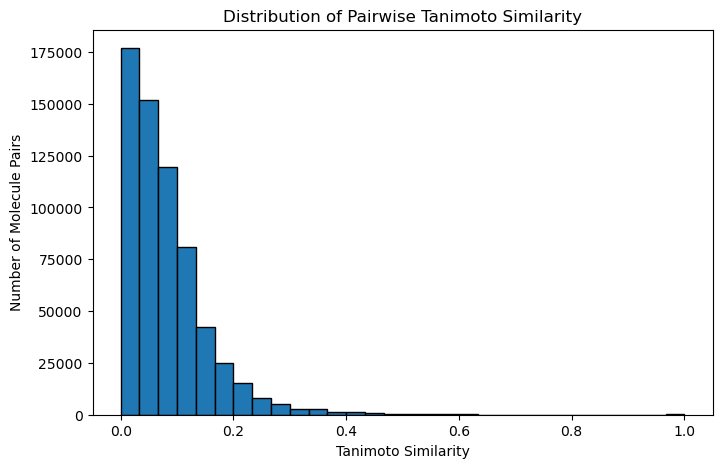

In [7]:
# Visualize the Similarity Distribution

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(
    similarities,
    bins=30,
    edgecolor="black"
)

plt.xlabel("Tanimoto Similarity")
plt.ylabel("Number of Molecule Pairs")
plt.title("Distribution of Pairwise Tanimoto Similarity")

plt.show()

The x-axis represents the Tanimoto similarity between pairs of molecules (0 to 1), while the y-axis shows the number of molecule pairs with that similarity.
Your histogram shows:
Most molecule pairs have similarity between 0.0 and 0.1.
Very few pairs have similarity above 0.3.
Almost no pairs have similarity greater than 0.5.
This means the ESOL dataset contains many structurally different molecules and very few highly similar pairs.

## Interpretation

The pairwise Tanimoto similarity distribution shows that the majority of molecule pairs have similarity values below 0.1.

This indicates that most molecules in the ESOL dataset are structurally different from one another.

The calculated diversity score of 0.921 further confirms that the ESOL dataset has high chemical diversity.

A highly diverse dataset covers a broader chemical space, making it suitable for applications such as QSAR modeling, virtual screening, and machine learning, where exposure to a wide range of chemical structures is beneficial.

Only a small proportion of molecule pairs exhibit moderate or high similarity, indicating that structural redundancy within the dataset is low.